# 05 — Annual rebalance: HRP-CVaR + Black-Litterman tilt

Same 4-ETF universe as notebook 04 (SWDA.L, XLK, IAU, BIL), but with:
- **Hierarchical Risk Parity** (Riskfolio-Lib `HCPortfolio`) using **CVaR** as the risk measure
- **Black-Litterman** posterior (Riskfolio `Portfolio.blacklitterman_stats`) to tilt toward a prior view
- **Annual rebalance** on the first trading day of each calendar year, using a 3-year lookback

### Why we pin BIL at 25%

BIL is ultra-short T-bills — daily vol ~0.01% — so pure HRP-CVaR dumps ≥94% into it (all the others look "risky" relative to cash). That collapses the portfolio to a cash account. We **pin BIL at 25%** (the user's category-slot design) and let HRP-CVaR allocate the remaining 75% across the 3 risky ETFs. The notebook also shows the pure-HRP variant for comparison.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

import macro_framework as mf

pd.set_option("display.width", 180)

## 1. Setup

In [2]:
INIT_CASH = 10_000.0
SIM_START = "2016-01-31"
SIM_END = "2026-01-31"
LOOKBACK_DAYS = 756       # ~3 trading years
CASH_PIN = {"BIL": 0.25}

spec = pd.read_parquet(Path.cwd().parent / "data" / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
BENCHMARK = "SPY"

# Pull enough history for the 3y lookback before SIM_START
prices = mf.get_prices(SYMBOLS + [BENCHMARK], start="2013-01-01", end=SIM_END)
rebalance_dates = mf.annual_rebalance_dates(prices, start=SIM_START)
print(f"rebalance dates ({len(rebalance_dates)}):")
print([d.date().isoformat() for d in rebalance_dates])

rebalance dates (11):
['2016-02-01', '2017-01-03', '2018-01-02', '2019-01-02', '2020-01-02', '2021-01-04', '2022-01-03', '2023-01-03', '2024-01-02', '2025-01-02', '2026-01-02']


## 2. Define strategies

All three weight functions take a window of historical daily returns and return target weights summing to 1.

In [3]:
# BL view: SWDA.L (world equity) outperforms BIL (cash) by 5% annualized.
#   P has one row per view, one column per asset (same order as returns/prices)
#   Q gives the expected excess return of the view at the returns frequency (daily)
VIEW_P = pd.DataFrame([[1, 0, 0, -1]], columns=SYMBOLS)
VIEW_Q = pd.DataFrame([[0.05 / 252]])  # 5% per year → per trading day
BL_TILT = 0.30  # 30% blend toward BL-MV weights, 70% HRP


def strat_hrp_pure(rets):
    return mf.hrp_cvar_weights(rets)


def strat_hrp_pinned(rets):
    return mf.hrp_cvar_weights_with_fixed(rets, fixed_weights=CASH_PIN)


def strat_hrp_pinned_bl(rets):
    w_hrp = mf.hrp_cvar_weights_with_fixed(rets, fixed_weights=CASH_PIN)
    w_bl = mf.bl_mv_weights(rets, prior_weights=w_hrp, P=VIEW_P, Q=VIEW_Q, obj="Utility")
    w = (1.0 - BL_TILT) * w_hrp + BL_TILT * w_bl
    return w / w.sum()

## 3. Build target-weight schedules

In [4]:
targets = {
    "A pure HRP-CVaR":      mf.build_target_weights(prices[SYMBOLS], strat_hrp_pure,       rebalance_dates, LOOKBACK_DAYS),
    "B pinned HRP-CVaR":    mf.build_target_weights(prices[SYMBOLS], strat_hrp_pinned,     rebalance_dates, LOOKBACK_DAYS),
    "C pinned HRP + BL":    mf.build_target_weights(prices[SYMBOLS], strat_hrp_pinned_bl,  rebalance_dates, LOOKBACK_DAYS),
}

weights_view = pd.concat(
    {name: t.loc[rebalance_dates].round(3) for name, t in targets.items()}, axis=0, names=["strategy", "rebalance"]
)
weights_view

symbol                        SWDA.L    XLK    IAU    BIL
strategy          rebalance                              
A pure HRP-CVaR   2016-02-01   0.012  0.011  0.010  0.967
                  2017-01-03   0.014  0.012  0.015  0.960
                  2018-01-02   0.018  0.015  0.021  0.946
                  2019-01-02   0.030  0.021  0.040  0.909
                  2020-01-02   0.040  0.026  0.070  0.864
                  2021-01-04   0.028  0.018  0.046  0.909
                  2022-01-03   0.022  0.014  0.029  0.936
                  2023-01-03   0.020  0.012  0.023  0.945
                  2024-01-02   0.071  0.041  0.071  0.817
                  2025-01-02   0.107  0.051  0.088  0.754
                  2026-01-02   0.126  0.063  0.092  0.719
B pinned HRP-CVaR 2016-02-01   0.231  0.215  0.304  0.250
                  2017-01-03   0.220  0.184  0.346  0.250
                  2018-01-02   0.209  0.173  0.368  0.250
                  2019-01-02   0.207  0.144  0.399  0.250
                  2020-01-02   0.183  0.123  0.444  0.250
                  2021-01-04   0.189  0.119  0.441  0.250
                  2022-01-03   0.208  0.130  0.412  0.250
                  2023-01-03   0.205  0.124  0.422  0.250
                  2024-01-02   0.227  0.132  0.390  0.250
                  2025-01-02   0.234  0.126  0.390  0.250
                  2026-01-02   0.255  0.145  0.350  0.250
C pinned HRP + BL 2016-02-01   0.274  0.182  0.257  0.287
                  2017-01-03   0.216  0.206  0.403  0.175
                  2018-01-02   0.169  0.197  0.459  0.175
                  2019-01-02   0.165  0.176  0.483  0.175
                  2020-01-02   0.128  0.173  0.524  0.175
                  2021-01-04   0.133  0.184  0.508  0.175
                  2022-01-03   0.146  0.207  0.472  0.175
                  2023-01-03   0.197  0.149  0.479  0.175
                  2024-01-02   0.159  0.220  0.446  0.175
                  2025-01-02   0.164  0.222  0.439  0.175
                  2026-01-02   0.178  0.245  0.402  0.175

## 4. Run simulations

In [5]:
pfs = {name: mf.run_rebalance_sim(prices[SYMBOLS], t, init_cash=INIT_CASH) for name, t in targets.items()}

# Baselines
pfs["EW B&H (nb 04)"] = mf.buy_and_hold(prices[SYMBOLS], dict(zip(SYMBOLS, [0.25] * 4)), init_cash=INIT_CASH)
pfs[f"{BENCHMARK} B&H"] = mf.single_asset_buy_and_hold(prices[BENCHMARK], init_cash=INIT_CASH)


def row(pf):
    return {
        "total_return":          float(pf.total_return()),
        "annualized_return":     float(pf.annualized_return()),
        "annualized_volatility": float(pf.annualized_volatility()),
        "sharpe_ratio":          float(pf.sharpe_ratio()),
        "sortino_ratio":         float(pf.sortino_ratio()),
        "calmar_ratio":          float(pf.calmar_ratio()),
        "max_drawdown":          float(pf.max_drawdown()),
    }


stats = pd.DataFrame({name: row(pf) for name, pf in pfs.items()}).round(4)
stats

,A pure HRP-CVaR,B pinned HRP-CVaR,C pinned HRP + BL,EW B&H (nb 04),SPY B&H
total_return,0.1524,2.2405,2.6228,3.6007,3.7376
annualized_return,0.0162,0.1421,0.1566,0.1882,0.1884
annualized_volatility,0.0155,0.0877,0.1004,0.1533,0.2040
sharpe_ratio,1.0432,1.5598,1.4988,1.2019,0.9483
sortino_ratio,1.3772,2.2702,2.1848,1.7020,1.3306
calmar_ratio,0.4997,1.1972,1.0983,0.8427,0.5523
max_drawdown,-0.0323,-0.1187,-0.1426,-0.2234,-0.3410


## 5. Equity curves & drawdowns

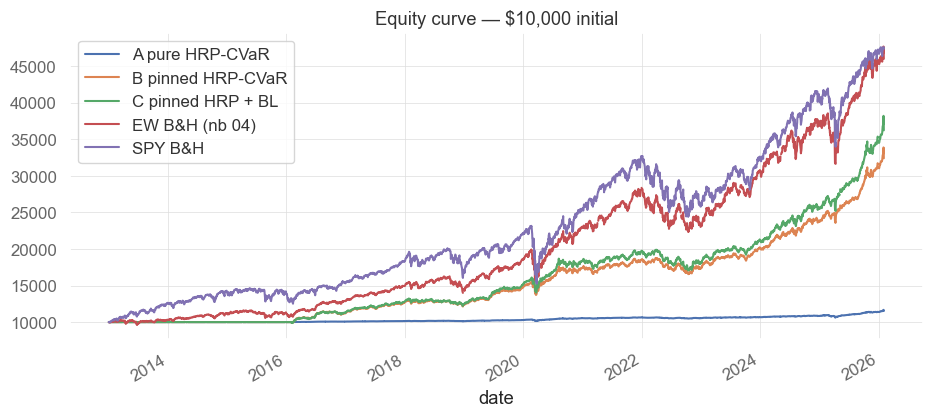

In [6]:
equity = pd.DataFrame({name: pf.value() for name, pf in pfs.items()})
equity.plot(figsize=(11, 4.5), title=f"Equity curve — ${INIT_CASH:,.0f} initial", grid=True);

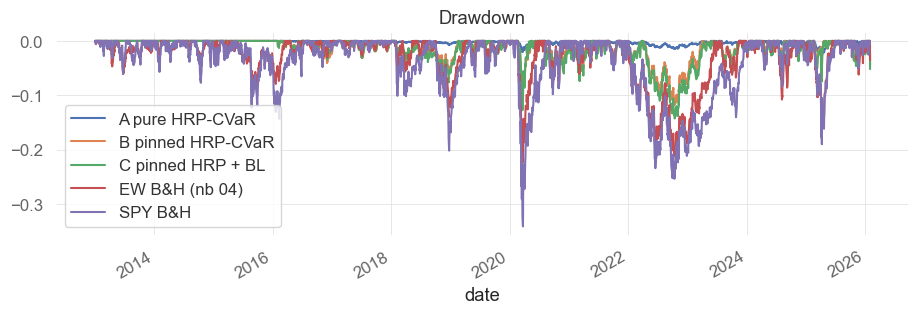

In [7]:
dd = pd.DataFrame({name: pf.drawdown() for name, pf in pfs.items()})
dd.plot(figsize=(11, 3), title="Drawdown", grid=True);

## 6. Notes

- **Pure HRP-CVaR** degenerates to ~97% cash because BIL's CVaR is ~0. That's the "correct" HRP-CVaR output given the inputs; it just isn't the allocation the user intended. Reported for completeness.
- **Pinned HRP-CVaR** keeps the 25% cash sleeve and lets HRP-CVaR re-balance the 3 risky ETFs annually — this is the operationally meaningful baseline.
- **Pinned HRP + BL tilt** adds one view (world equity outperforms cash by 5%/yr) and blends 30% toward the BL posterior. With only one directional view the marginal impact is small; tilts stack up if you add more views.
- **Still in-sample** on the SSR selection. A clean walk-forward would re-score the universe each year and let the category picks rotate.